In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Ready to reshape some vectors!")

Ready to reshape some vectors!


In [2]:
alice = np.array([8.0, 5.0, 50.0])
bob = np.array([3.0, 9.0, 20.0])

dot = np.dot(alice, bob)
cos_sim = dot / (np.linalg.norm(alice) * np.linalg.norm(bob))
print(f"Alice's feature vector: {alice}")
print(f"Bob's feature vector:   {bob}")
print(f"Dot product:  {dot:.2f}")
print(f"Cosine similarity:  {cos_sim:.4f}")
print(f"L2 distance: {np.linalg.norm(alice - bob):.4f}")

Alice's feature vector: [ 8.  5. 50.]
Bob's feature vector:   [ 3.  9. 20.]
Dot product:  1069.00
Cosine similarity:  0.9491
L2 distance: 30.6757


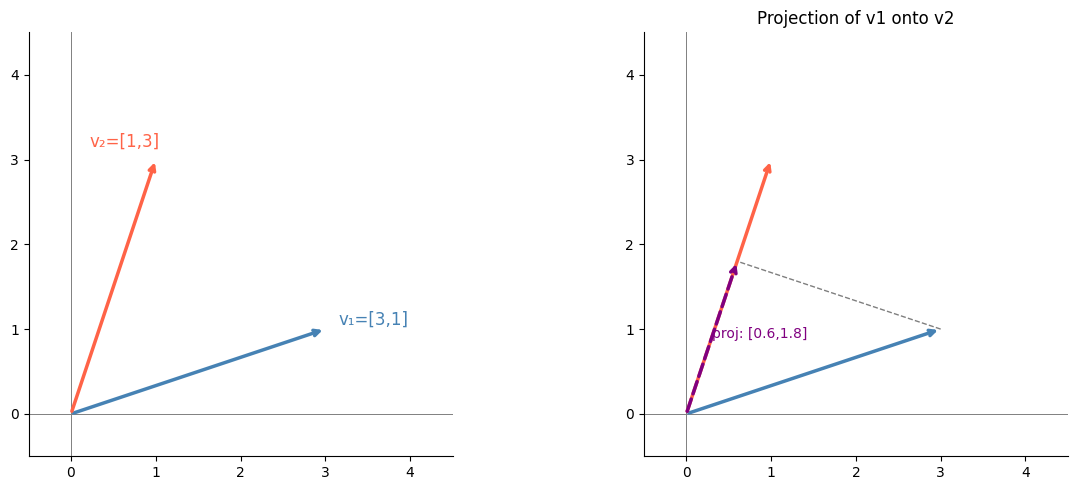

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
v1 = np.array([3, 1])
v2 = np.array([1, 3])

ax = axes[0]
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 4.5)
ax.axhline(0, color='gray', lw=0.7); ax.axvline(0, color='gray', lw=0.7)
ax.annotate('', xy=v1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.annotate('', xy=v2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='tomato', lw=2.5))
ax.text(*v1*1.05, 'v₁=[3,1]', fontsize=12, color='steelblue', ha='left')
ax.text(*v2*1.05, 'v₂=[1,3]', fontsize=12, color='tomato', ha='right')
angle = np.degrees(np.arccos(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))))
Dot_product = {np.dot(v1,v2)}
ax.set_aspect('equal')

proj = (np.dot(v1, v2) / np.dot(v2, v2)) * v2
ax2 = axes[1]
ax2.set_xlim(-0.5, 4.5); ax2.set_ylim(-0.5, 4.5)
ax2.axhline(0, color='gray', lw=0.7); ax2.axvline(0, color='gray', lw=0.7)
ax2.annotate('', xy=v1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax2.annotate('', xy=v2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='tomato', lw=2.5))
ax2.annotate('', xy=proj, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='purple', lw=2.5, ls='--'))
ax2.plot([v1[0], proj[0]], [v1[1], proj[1]], 'k--', lw=1, alpha=0.5)
ax2.text(*proj*0.5, f'proj: [{proj[0]:.1f},{proj[1]:.1f}]', color='purple', fontsize=10)
ax2.set_title('Projection of v1 onto v2')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()


In [4]:
def matmul_scratch(A, B):
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, f"Shape mismatch: shape of A = {A.shape}, shape of B = {B.shape}"

    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for l in range(k):
                C[i, j] += A[i, l] * B[l, j]
    return C

A = np.array([[1, 2, 3], [4, 5, 6]], dtype=float)  
B = np.array([[7, 8], [9, 10], [11, 12]], dtype=float) 

C_scratch = matmul_scratch(A, B)
C_numpy   = A @ B

print("Matrix A (2×3):")
print(A)
print("\nMatrix B (3×2):")
print(B)
print("\nC = A @ B  (our implementation):")
print(C_scratch)
print("\nVerification against NumPy:", np.allclose(C_scratch, C_numpy))
print("\nUnderstanding: C[0,0] = row0(A)·col0(B) = 1×7 + 2×9 + 3×11 =", 1*7+2*9+3*11)

Matrix A (2×3):
[[1. 2. 3.]
 [4. 5. 6.]]

Matrix B (3×2):
[[ 7.  8.]
 [ 9. 10.]
 [11. 12.]]

C = A @ B  (our implementation):
[[ 58.  64.]
 [139. 154.]]

Verification against NumPy: True

Understanding: C[0,0] = row0(A)·col0(B) = 1×7 + 2×9 + 3×11 = 58


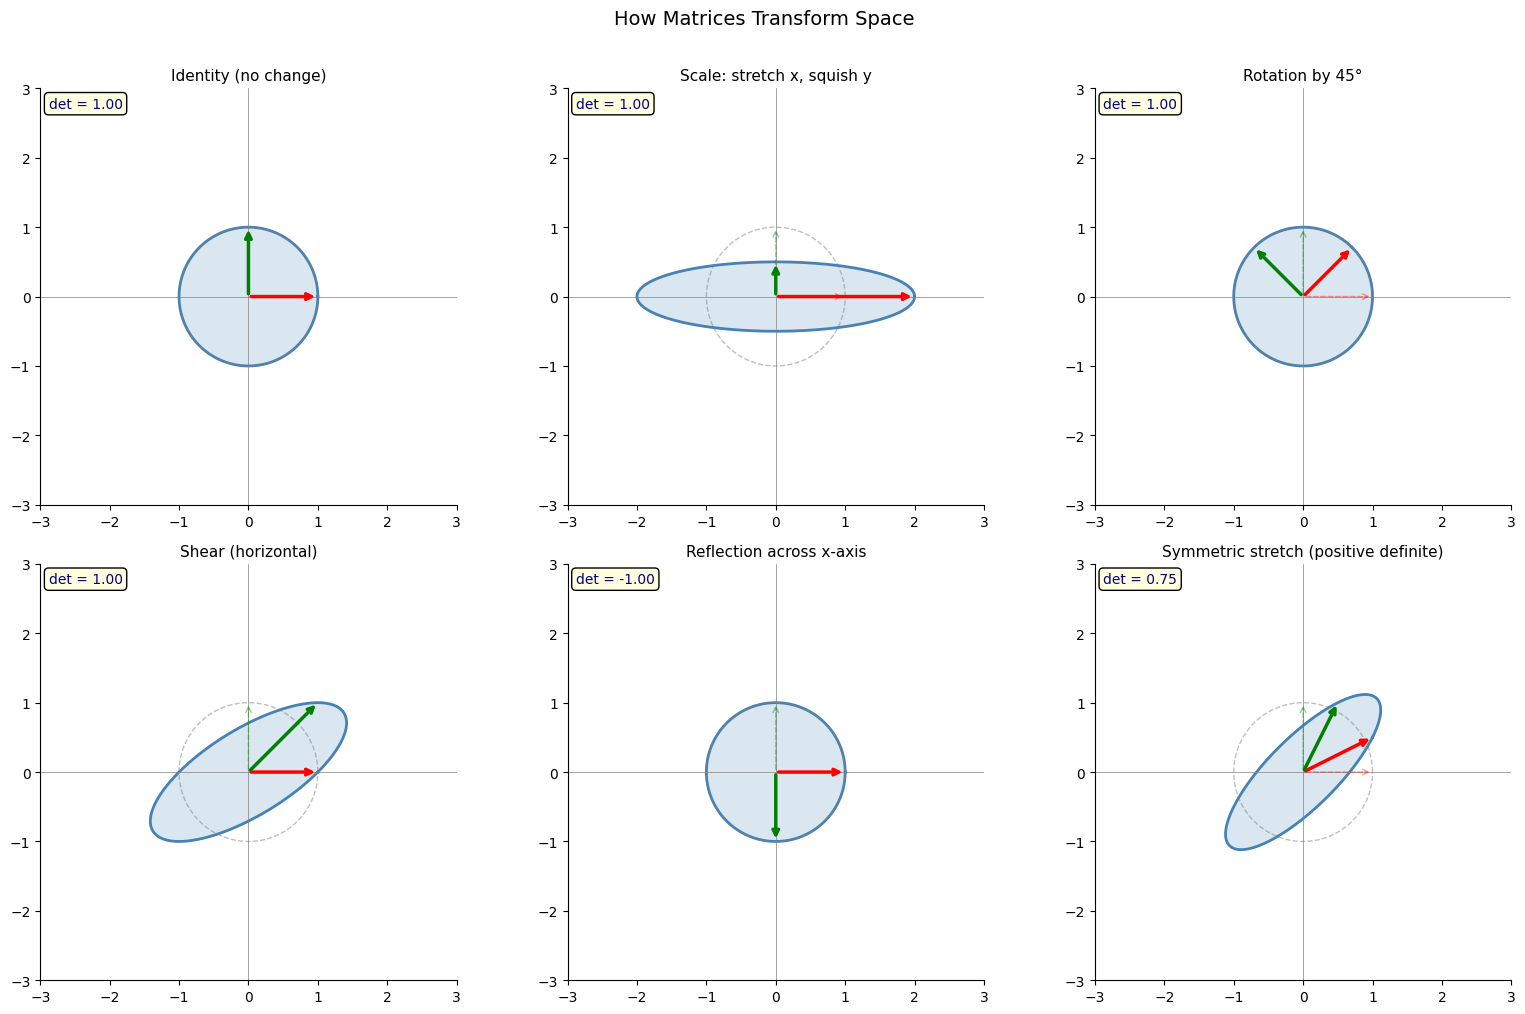

In [8]:
def transform_and_plot(M, title, ax):
    theta = np.linspace(0, 2*np.pi, 200)
    circle = np.array([np.cos(theta), np.sin(theta)])
    transformed = M @ circle

    e1, e2 = np.array([1, 0]), np.array([0, 1])
    Me1, Me2 = M @ e1, M @ e2
    ax.fill(transformed[0], transformed[1], alpha=0.2, color='steelblue')
    ax.plot(transformed[0], transformed[1], 'steelblue', lw=2)
    ax.plot(circle[0], circle[1], 'gray', lw=1, ls='--', alpha=0.5)
    arrow_kw = dict(arrowstyle='->', lw=2.5)
    ax.annotate('', xy=Me1, xytext=(0,0), arrowprops=dict(**arrow_kw, color='red'))
    ax.annotate('', xy=Me2, xytext=(0,0), arrowprops=dict(**arrow_kw, color='green'))
    ax.annotate('', xy=e1, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='red', lw=1, ls='dashed', alpha=0.4))
    ax.annotate('', xy=e2, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='green', lw=1, ls='dashed', alpha=0.4))

    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    lim = max(3, np.abs(transformed).max() * 1.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.text(0.02, 0.98, f'det = {np.linalg.det(M):.2f}', transform=ax.transAxes,
            va='top', fontsize=10, color='navy',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
transforms = [
    (np.eye(2), 'Identity (no change)'),
    (np.array([[2,0],[0,0.5]]), 'Scale: stretch x, squish y'),
    (np.array([[np.cos(np.pi/4),-np.sin(np.pi/4)],[np.sin(np.pi/4),np.cos(np.pi/4)]]), 'Rotation by 45°'),
    (np.array([[1,1],[0,1]]), 'Shear (horizontal)'),
    (np.array([[1,0],[0,-1]]), 'Reflection across x-axis'),
    (np.array([[1,0.5],[0.5,1]]), 'Symmetric stretch (positive definite)'),
]

for (M, title), ax in zip(transforms, axes.flat):
    transform_and_plot(M, title, ax)

plt.suptitle('How Matrices Transform Space', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

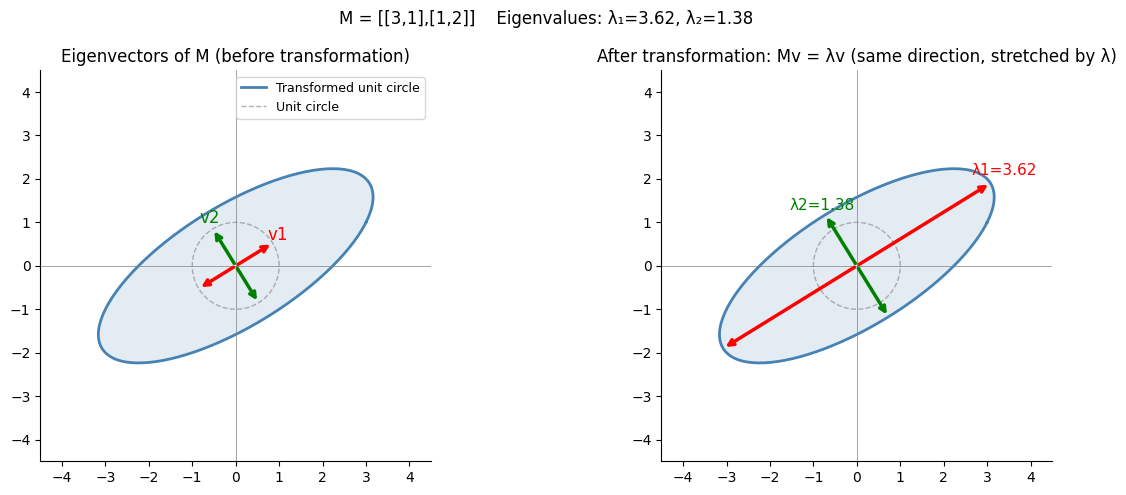

In [9]:
M = np.array([[3, 1], [1, 2]], dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(M)

theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])
transformed = M @ circle

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax in axes:
    ax.fill(transformed[0], transformed[1], alpha=0.15, color='steelblue')
    ax.plot(transformed[0], transformed[1], 'steelblue', lw=2, label='Transformed unit circle')
    ax.plot(circle[0], circle[1], 'gray', lw=1, ls='--', alpha=0.6, label='Unit circle')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal'); ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)

colors = ['red', 'green']
for i, (ev, lam) in enumerate(zip(eigenvectors.T, eigenvalues)):
    ev = ev.real; lam = lam.real
    axes[0].annotate('', xy=ev, xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    axes[0].annotate('', xy=-ev, xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    axes[0].text(*ev*1.15, f'v{i+1}', color=colors[i], fontsize=12, ha='center')
    
    Mev = M @ ev
    axes[1].annotate('', xy=Mev, xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    axes[1].annotate('', xy=-Mev, xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    axes[1].text(*Mev*1.1, f'λ{i+1}={lam:.2f}', color=colors[i], fontsize=11, ha='center')

axes[0].set_title('Eigenvectors of M (before transformation)'); axes[0].legend(fontsize=9)
axes[1].set_title('After transformation: Mv = λv (same direction, stretched by λ)')
plt.suptitle(f'M = [[3,1],[1,2]]    Eigenvalues: λ₁={eigenvalues[0].real:.2f}, λ₂={eigenvalues[1].real:.2f}', fontsize=12)
plt.tight_layout()
plt.show()

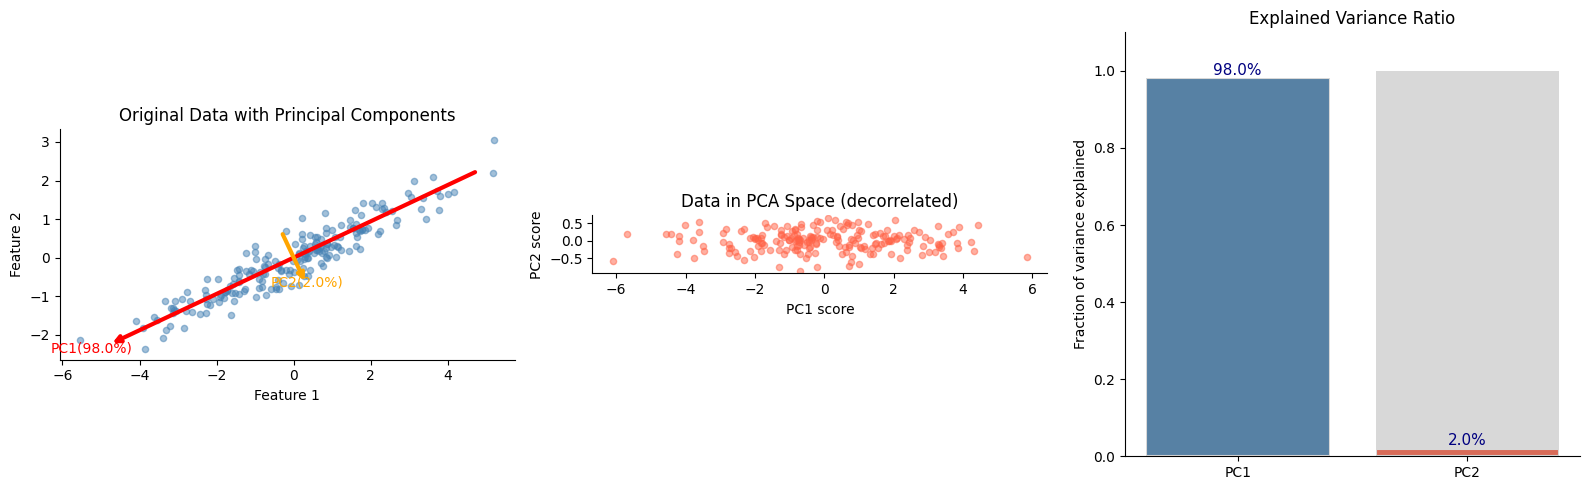

PC1 explains 98.0% of variance
PC2 explains 2.0% of variance


In [15]:
np.random.seed(42)
n = 200
t = np.random.randn(n)
X = np.column_stack([2*t + 0.3*np.random.randn(n), t + 0.3*np.random.randn(n)])

def pca_from_scratch(X, num_components=None):
    X_centered = X - X.mean(axis=0)
    n = X.shape[0]
    cov = (X_centered.T @ X_centered) / (n - 1)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    if num_components:
        eigenvectors = eigenvectors[:, :num_components]
        eigenvalues = eigenvalues[:num_components]
    
    X_projected = X_centered @ eigenvectors
    return X_projected, eigenvectors, eigenvalues, X_centered

X_proj, components, variances, X_c = pca_from_scratch(X, num_components=2)

total_var = variances.sum()
evr = variances / total_var

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.5, s=20, color='steelblue')
for i, (comp, ev_ratio) in enumerate(zip(components.T, evr)):
    scale = np.sqrt(variances[i]) * 2.5
    axes[0].annotate('', xy=comp*scale, xytext=-comp*scale,
                     arrowprops=dict(arrowstyle='->', lw=3,
                                     color=['red','orange'][i]))
    axes[0].text(*comp*scale*1.1, f'PC{i+1}({ev_ratio:.1%})',color=['red','orange'][i], fontsize=10, ha='center')
axes[0].set_aspect('equal')
axes[0].set_title('Original Data with Principal Components')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, s=20, color='tomato')
axes[1].set_title('Data in PCA Space (decorrelated)')
axes[1].set_xlabel('PC1 score'); axes[1].set_ylabel('PC2 score')
axes[1].set_aspect('equal')

axes[2].bar(['PC1', 'PC2'], evr, color=['steelblue', 'tomato'], edgecolor='white', lw=1.5)
axes[2].bar(['PC1', 'PC2'], np.cumsum(evr), alpha=0.3, color=['gray', 'gray'])
for i, (ev, cev) in enumerate(zip(evr, np.cumsum(evr))):
    axes[2].text(i, ev + 0.01, f'{ev:.1%}', ha='center', fontsize=11, color='navy')
axes[2].set_title('Explained Variance Ratio'); axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel('Fraction of variance explained')

plt.tight_layout()
plt.show()
print(f"PC1 explains {evr[0]:.1%} of variance")
print(f"PC2 explains {evr[1]:.1%} of variance")


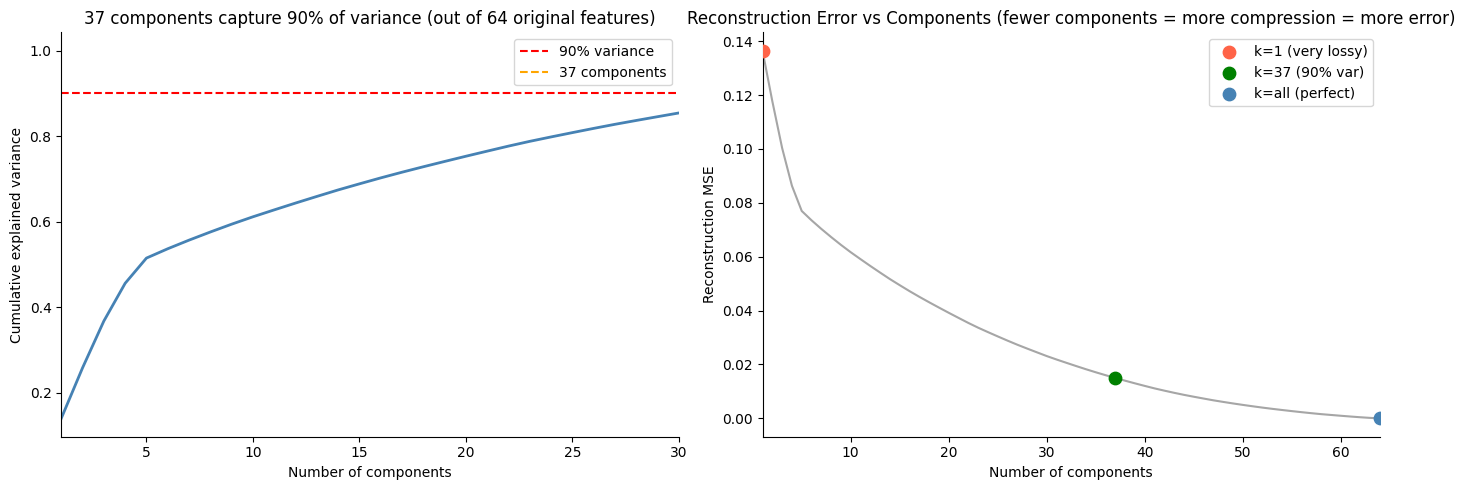

In [16]:
np.random.seed(0)
n_samples, n_features = 150, 64

true_components = np.random.randn(5, n_features)
true_components /= np.linalg.norm(true_components, axis=1, keepdims=True)

weights = np.random.randn(n_samples, 5)
X_faces = weights @ true_components + 0.3*np.random.randn(n_samples, n_features)

X_pca, comps, evs, X_c = pca_from_scratch(X_faces)
evr_faces = evs / evs.sum()

cumulative = np.cumsum(evr_faces)
n90 = np.searchsorted(cumulative, 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(evr_faces)+1), cumulative, 'steelblue', lw=2)
axes[0].axhline(0.90, color='red', ls='--', label='90% variance')
axes[0].axvline(n90, color='orange', ls='--', label=f'{n90} components')
axes[0].set_xlabel('Number of components'); axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title(f'{n90} components capture 90% of variance (out of {n_features} original features)')
axes[0].legend(); axes[0].set_xlim(1, 30)

X_c2 = X_faces - X_faces.mean(0)
for k, color, label in [(1,'tomato','k=1 (very lossy)'), (n90,'green',f'k={n90} (90% var)'), (n_features,'steelblue','k=all (perfect)')]:
    comps_k = comps[:, :k]
    X_recon = (X_c2 @ comps_k) @ comps_k.T + X_faces.mean(0)
    mse = np.mean((X_faces - X_recon)**2)
    axes[1].scatter(k, mse, color=color, s=80, label=label, zorder=5)

k_range = range(1, n_features+1)
mses = []
for k in k_range:
    comps_k = comps[:, :k]
    X_recon = (X_c2 @ comps_k) @ comps_k.T + X_faces.mean(0)
    mses.append(np.mean((X_faces - X_recon)**2))

axes[1].plot(k_range, mses, 'gray', lw=1.5, alpha=0.7)
axes[1].set_xlabel('Number of components'); axes[1].set_ylabel('Reconstruction MSE')
axes[1].set_title('Reconstruction Error vs Components (fewer components = more compression = more error)')
axes[1].legend(); axes[1].set_xlim(1, n_features)

plt.tight_layout()
plt.show()

In [17]:
np.random.seed(42)
n = 200
t = np.random.randn(n)
X = np.column_stack([2*t + 0.3*np.random.randn(n), t + 0.3*np.random.randn(n)])

X_centered = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X_centered)
_, pca_eigenvectors, _, _ = pca_from_scratch(X)

svd_components = Vt.T 

print("PCA Eigenvectors:\n", pca_eigenvectors)
print("\nSVD Singular Vectors:\n", svd_components)

PCA Eigenvectors:
 [[-0.90463637  0.42618427]
 [-0.42618427 -0.90463637]]

SVD Singular Vectors:
 [[-0.90463637 -0.42618427]
 [-0.42618427  0.90463637]]


In [18]:
np.random.seed(42)
n = 300
x_base = np.random.normal(0, 2.0, n)
y_base = np.random.normal(0, 0.5, n)
X_base = np.column_stack([x_base, y_base])

def get_rotation_matrix(angle_degrees):
    theta = np.radians(angle_degrees)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

R30 = get_rotation_matrix(30)
R60 = get_rotation_matrix(60)

X_30 = X_base @ R30.T
X_60 = X_base @ R60.T

def run_pca(X):
    X_centered = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X_centered)
    return Vt.T

components_30 = run_pca(X_30)
components_60 = run_pca(X_60)

angle_PC1_30 = np.degrees(np.arctan2(components_30[1, 0], components_30[0, 0]))
angle_PC1_60 = np.degrees(np.arctan2(components_60[1, 0], components_60[0, 0]))

print(f"Data rotated 30° -> PCA finds PC1 angle at: {angle_PC1_30:.2f}°")
print(f"Data rotated 60° -> PCA finds PC1 angle at: {angle_PC1_60:.2f}°")

Data rotated 30° -> PCA finds PC1 angle at: -150.60°
Data rotated 60° -> PCA finds PC1 angle at: -120.60°


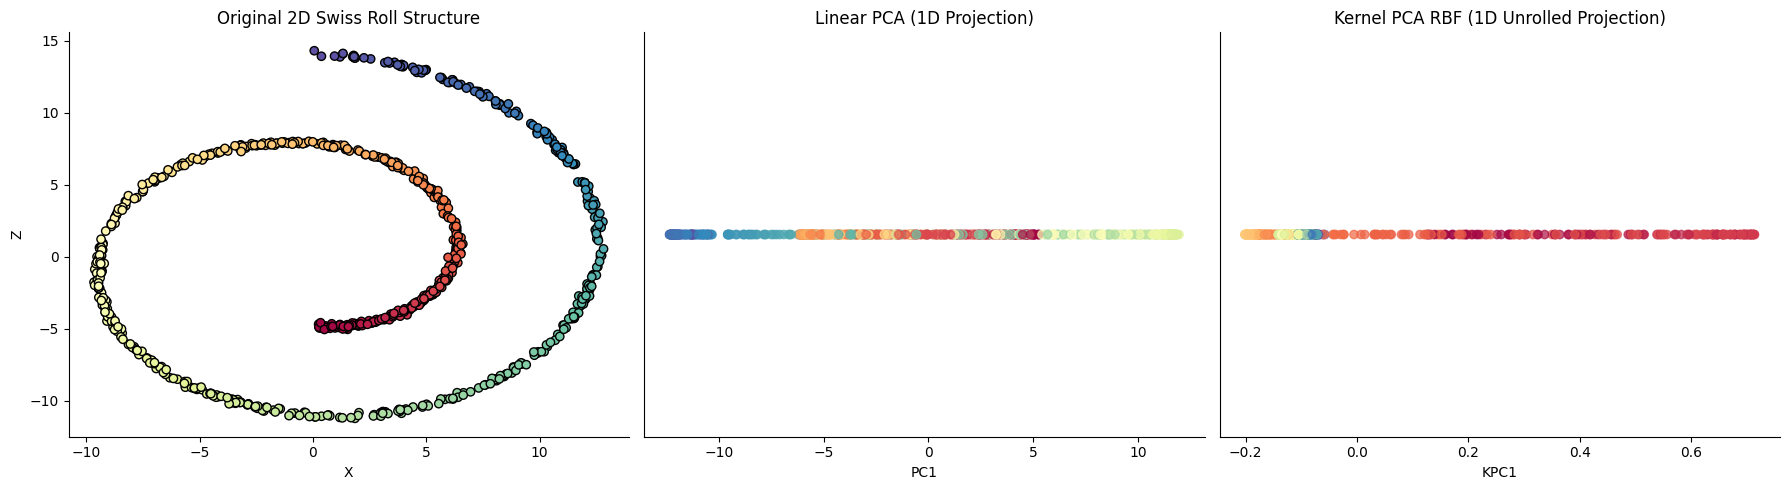

In [21]:
from sklearn.datasets import make_swiss_roll

np.random.seed(42)
X_swiss, color = make_swiss_roll(n_samples=800, noise=0.1)
X_2d = X_swiss[:, [0, 2]] 

def linear_pca(X, n_components=1):
    X_centered = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X_centered)
    return X_centered @ Vt.T[:, :n_components]

def kernel_pca_rbf(X, gamma=0.1, n_components=1):
    n = X.shape[0]
    
    sq_dists = np.sum(X**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * (X @ X.T)
    
    K = np.exp(-gamma * sq_dists)
    
    I_n = np.ones((n, n)) / n
    K_centered = K - I_n @ K - K @ I_n + I_n @ K @ I_n
    
    U, S, Vt = np.linalg.svd(K_centered)
    X_kpca = U[:, :n_components] * np.sqrt(S[:n_components])
    
    return X_kpca

X_linear_1d = linear_pca(X_2d, n_components=1)
X_kernel_1d = kernel_pca_rbf(X_2d, gamma=0.3, n_components=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=color, cmap=plt.cm.Spectral, edgecolor='k')
axes[0].set_title("Original 2D Swiss Roll Structure")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Z")

axes[1].scatter(X_linear_1d, np.zeros_like(X_linear_1d), c=color, cmap=plt.cm.Spectral, alpha=0.7)
axes[1].set_title("Linear PCA (1D Projection)")
axes[1].set_xlabel("PC1")
axes[1].get_yaxis().set_visible(False)

axes[2].scatter(X_kernel_1d, np.zeros_like(X_kernel_1d), c=color, cmap=plt.cm.Spectral, alpha=0.7)
axes[2].set_title("Kernel PCA RBF (1D Unrolled Projection)")
axes[2].set_xlabel("KPC1")
axes[2].get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()